# [PBT] 화장품 이커머스 ㅣ 10. 이변량 — B조 · 상품·상황 4종 〈배지환〉

## 이 노트북이 하는 일

교재 EDA **STEP 3 이변량** 중 B조 몫이다 — `[LAB-08 4단원 p.3]`
묻는 것 : **종속을 설명하는가** (채택 근거 ① 관련성 · ② 효과크기)

```
연속형 1 : price
명목형 3 : brand_grp(15) · cart_timeband(4) · cart_weekday(7)
```

`category_grp`은 **이변량을 하지 않는다.** 06번에서 설명변수 분포만 보고 제외를 확정했고,
여기서 Y와의 관계를 보면 그 규율이 깨진다(설계 §1-2).

## 여기서 하지 않는 것

| 안 하는 것 | 어디서 |
|---|---|
| **다변량 · VIF · 변수 선택** | **`10c` — 둘이 함께.** 나눌 수 없다(설계 §4-1) |
| 스코어카드 판정 | `10c` — 둘이 함께 |
| 명목형 3종의 다변량 | ⑤ 모델링 — 더미 전개는 **분할 후** (LAB-13 04) |
| A조 4종 | `10a` (이슬기) |

## 🔴 여기서 Y를 처음 본다

`09`번 단변량 전체에서 `purchase_7d`와의 관계를 한 번도 보지 않았다.
그 덕분에 판정 기준이 결과에 오염되지 않았다. **기준은 `09_EDA_설계_초안.md`에 이미 확정되어 있다.**

## 진입 전 확정된 것 — 설계 §7 검토 포인트 ①·④

### ① 연속형 X의 효과크기 → **`anova_oneway`의 `np2`를 쓴다**

교재는 우리 조합(연속 X ↔ 이진 Y)의 효과크기를 **제공하지 않는다** — `[LAB-07 5단원]` 44쪽에 효과크기라는
단어가 없고, `[LAB-08 3단원 p.10]`은 Cohen's d를 이름만 들며, 교재 자신의 채택표도 **"미제공"**으로 비웠다.

**그런데 교재 도구로 채울 수 있다.**

| 확인 | 근거 |
|---|---|
| `anova_oneway`가 2집단에서 돌고 `np2`를 반환한다 | 설계 §2-3 (가짜 데이터로 확인) |
| 기준선 0.01/0.06/0.14의 출처 | `[LAB-07 6단원 p.23]` — Cohen(1988), 쪽 제목에 명시 |
| 정규성 미충족인데 ANOVA를 써도 되는가 | `[LAB-07 6단원 p.3]` *"CLT 덕에 **ANOVA는 정규성에 흔들리지 않는다**"* (★ 약함) |
| 표본 불균형(22,236 vs 86,222) | `welch_anova` 자동 분기 (★★, 교재가 지정한 보정법) |

**비우는 쪽보다 이걸 고른 이유** — §3-3에 따라 **효과크기로 자르지 않으므로 판정이 달라지지 않는다.**
채워도 규율 위험이 없고, 비우면 결과표의 연속형 칸만 빈칸이 되어 보고서가 읽히지 않는다.

> **대가** — 교재가 *"이진 Y → T검정"*이라 지정한 조합에 ANOVA 계열 도구를 **효과크기 목적으로 함께** 쓴다.
> 「교재 미기재」는 아니지만(함수·기준선·출처 모두 교재 안) **보고서에 한 문장으로 밝힌다.**
> **주 검정은 `test_independent`**이고 p값·검정명은 거기서 가져온다.

### ④ 유의성의 용도 → **보고하되 자르지 않는다**

교재 채택근거 ①(관련성)은 `p < α`다 `[LAB-08 1단원 p.3]`. 확인하고 보고하되 **변별에는 쓰지 않는다.**
`[LAB-08 3단원 p.7]` 실수 06과 `[LAB-08 5단원 p.30·36]`(n=53,794, p=0.018인데 제외)이 같은 태도다.

## 📐 수치 표기 규칙 (설계 §4-5)

> 판정문의 모든 수치에 **어느 셀에서 나오는지**를 `#03-2` 형태로 적는다.
> 외부 문서 인용은 출처를 밝힌다. **둘 다 아닌 수치는 쓰지 않는다.**

---

## #01. 준비

In [1]:
import os, sys

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
os.chdir(BASE)
sys.path.insert(0, BASE)

from numpy import sqrt, abs as np_abs, where
from pandas import read_csv, to_datetime, DataFrame, Series, crosstab, set_option
from scipy.stats import chi2_contingency
from helpers import my_stats, my_prep, my_plot

set_option("display.max_columns", 50)
set_option("display.max_colwidth", 60)

OUT = BASE + r"\output"
ALPHA = 0.05
print("데이터 폴더 :", OUT)

데이터 폴더 : .\output


### 1-1. 마스터 테이블 + 08번 대조 — 하나라도 어긋나면 멈춘다

In [2]:
m = read_csv(OUT + r"\03_master.csv", encoding="utf-8-sig")

m["t0"]          = to_datetime(m["t0"], format="%Y-%m-%d %H:%M:%S")
m["product_id"]  = m["product_id"].astype("int32")
m["purchase_7d"] = m["purchase_7d"].astype("int8")
m["cart_timeband"] = m["cart_timeband"].astype("category").cat.set_categories(
    ["심야", "오전", "오후", "저녁"], ordered=True)
m["cart_weekday"]  = m["cart_weekday"].astype("category").cat.set_categories(
    ["월", "화", "수", "목", "금", "토", "일"], ordered=True)
for c in ["brand_grp", "category_grp"]:
    m[c] = m[c].astype("category")

# test_independent 는 wide 를 요구한다 (설계 §2-2 함정 ①). 라벨을 미리 만들어 둔다.
m["Y라벨"] = where(m["purchase_7d"] == 1, "구매", "미구매")

ok = [("행 수", f"{len(m):,}", "108,458"),
      ("1행 = 1고객", str(len(m) == m["user_id"].nunique()), "True"),
      ("Y 양성", f"{int(m['purchase_7d'].sum()):,}명 / {m['purchase_7d'].mean():.2%}", "22,236명 / 20.50%"),
      ("brand_grp", f"{m['brand_grp'].nunique()}종", "15종")]
chk = DataFrame(ok, columns=["항목", "이번 실행", "08번 값"])
chk["일치"] = chk["이번 실행"] == chk["08번 값"]
chk

,항목,이번 실행,08번 값,일치
0,행 수,"108,458","108,458",True
1,1행 = 1고객,True,True,True
2,Y 양성,"22,236명 / 20.50%","22,236명 / 20.50%",True
3,brand_grp,15종,15종,True


In [3]:
def _p(x):
    "함수가 소수 4자리로 반올림해 0.0 으로 찍는다. 보고서에 p = 0.0 이라고 쓰지 않는다 (설계 §3-1)."
    return "< 0.0001" if x < 0.0001 else f"{x:.4f}"


def cont_test(col):
    "연속형 X ↔ 이진 Y. 주 검정 + 효과크기를 한 번에."
    w = my_prep.long2wide(m[[col, "Y라벨"]], hue="Y라벨", values=col)
    r = my_stats.test_independent(w, "구매", "미구매", plot=False)
    two = r.xs("two-sided", level="alternative")
    a = my_stats.anova_oneway(m[[col, "purchase_7d"]], y=col, between="purchase_7d")
    g = m.groupby("Y라벨", observed=True)[col].mean()
    return {"변수": col,
            "검정": r.index.get_level_values("test")[0],
            "p": float(two["p-value"].iloc[0]),
            "ANOVA": str(a["test"].iloc[0]),
            "np2": round(float(a["np2"].iloc[0]), 5),
            "효과크기 라벨": str(a["effect_size"].iloc[0]),
            "구매 평균": round(g["구매"], 4), "미구매 평균": round(g["미구매"], 4)}


def nomi_test(col):
    "명목·이진 X ↔ 이진 Y. 교차분석."
    d = my_stats.chi2_independence(m, col, "purchase_7d", plot=False).iloc[0]
    return {"변수": col, "검정": str(d["test"]),
            "chi2": round(float(d["chi2"]), 3), "dof": int(d["dof"]),
            "p": float(d["p-value"]), "V": round(float(d["effect(V)"]), 4),
            "strength": str(d["strength"]),
            "min_expected": round(float(d["min_expected"]), 1),
            "가정 충족": bool(d["assumption"])}


def rate_by(col):
    "범주별 Y 비율 — 교재가 쓰는 서술 도구 [LAB-07 12단원 p.9]"
    g = m.groupby(col, observed=True)["purchase_7d"]
    return DataFrame({"고객 수": g.size(), "Y 비율(%)": (g.mean() * 100).round(2)})


print("공용 함수 4개 준비 완료 — cont_test · nomi_test · rate_by · _p")
print(f"전체 평균 Y 비율 : {m['purchase_7d'].mean() * 100:.2f}%")

공용 함수 4개 준비 완료 — cont_test · nomi_test · rate_by · _p
전체 평균 Y 비율 : 20.50%


---

## #02. 연속형 `price` — `test_independent` + `anova_oneway`

In [4]:
B_CONT_R = DataFrame([cont_test("price")]).set_index("변수")
B_CONT_R

,검정,p,ANOVA,np2,효과크기 라벨,구매 평균,미구매 평균
변수,,,,,,,
price,Mann-Whitney U test,0.0,welch_anova,0.0008,Negligible,11.295,9.8424


> **`p = 0.0`으로 찍히면 반올림 결과다.** 보고서에는 **`p < 0.0001`**로 적는다(설계 §3-1).
>
> **Mann-Whitney U가 나왔다면 예상대로다** — n = 108,458이라 `normaltest`가 사실상 항상 기각한다(설계 §2-2 함정 ②).
> 보고서에는 *"정규성이 충족되지 않아 Mann-Whitney U가 자동 적용되었다"*로 적는다. 교재도 같은 문장을 썼다 `[LAB-08 §4-4]`.

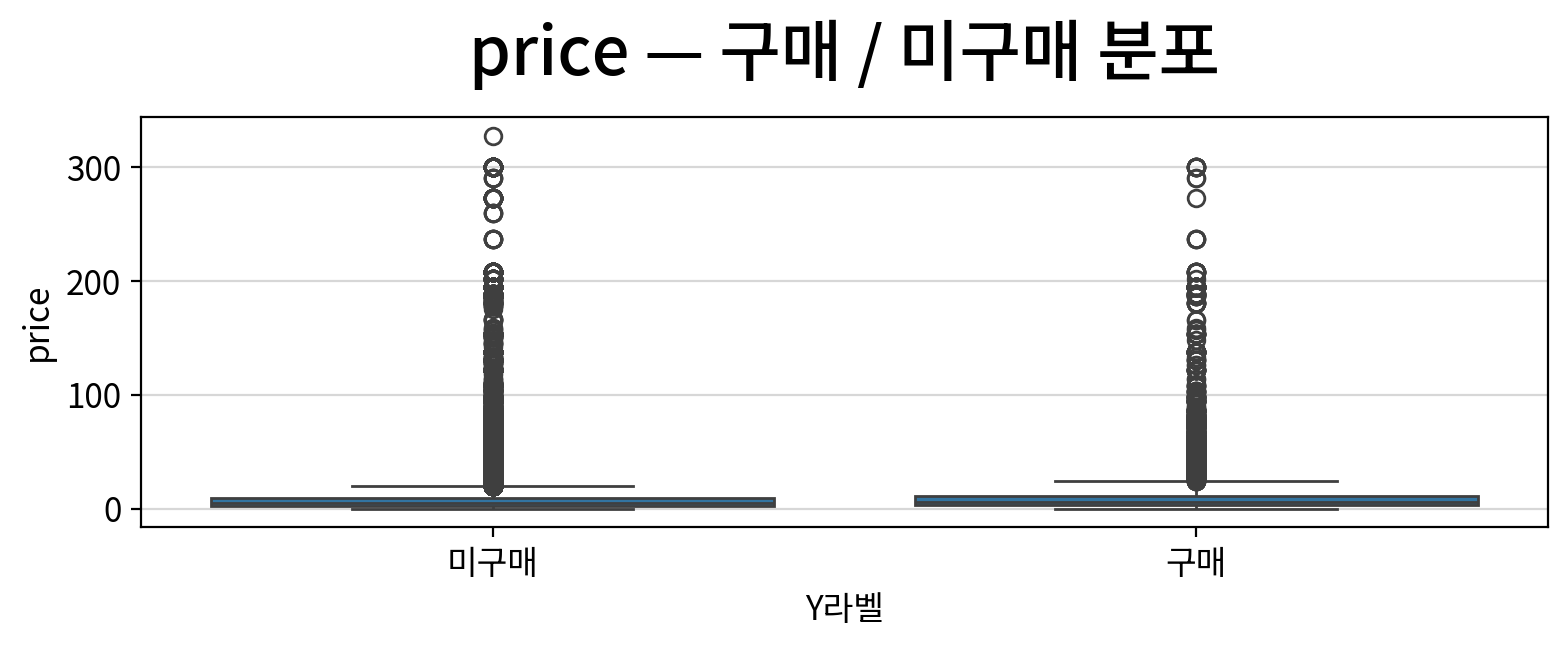

In [5]:
my_plot.boxplot(data=m, x="Y라벨", y="price",
                title="price — 구매 / 미구매 분포", width=800, height=340)

---

## #03. 명목형 3종 — 교차분석

In [6]:
B_NOMI = ["brand_grp", "cart_timeband", "cart_weekday"]

B_NOMI_R = DataFrame([nomi_test(c) for c in B_NOMI]).set_index("변수")
B_NOMI_R

,검정,chi2,dof,p,V,strength,min_expected,가정 충족
변수,,,,,,,,
brand_grp,Chi-square test of independence,401.358,14,0.0,0.0608,Negligible,314.7,True
cart_timeband,Chi-square test of independence,99.308,3,0.0,0.0303,Negligible,1867.1,True
cart_weekday,Chi-square test of independence,49.994,6,0.0,0.0215,Negligible,2865.8,True


> **`strength` 라벨은 판정에 쓰지 않는다**(설계 §3-3·§3-7).
> 코드는 4구간(`Negligible` 추가)인데 교재 본문은 3구간이고 **`Negligible`은 교재에 없는 등급**이다 `[LAB-07 §7-3 ①]`.
> 교재는 V의 해석선 **출처도 밝히지 않는다** — η²ₚ·Hedges' g는 Cohen(1988)을 명시하는데 V만 없다.
>
> ⚠️ **`min_expected`를 반드시 확인한다.** Fisher 자동 전환은 **2×2에서만** 일어난다(설계 §2-2 함정 ⑤).
>
> `brand_grp`은 **15×2**다. 가정이 깨져도 카이제곱이 그대로 돌고 `assumption`에 `False`만 찍힌다.

### 3-1. 범주별 Y 비율

In [7]:
for c in ["cart_timeband", "cart_weekday"]:
    print("=" * 46)
    print(f"{c}   (전체 평균 {m['purchase_7d'].mean() * 100:.2f}%)")
    display(rate_by(c))

cart_timeband   (전체 평균 20.50%)


,고객 수,Y 비율(%)
cart_timeband,,
심야,9107,17.78
오전,23663,20.73
오후,39186,21.80
저녁,36502,19.64


cart_weekday   (전체 평균 20.50%)


,고객 수,Y 비율(%)
cart_weekday,,
월,15558,20.79
화,14730,20.91
수,14758,21.52
목,15955,21.14
금,18235,20.72
토,15244,18.98
일,13978,19.31


### 3-2. `brand_grp` — 표준화 잔차

V 하나로는 *"관계가 있다"*까지만 알 수 있다. **어느 브랜드가 그 관계를 만드는지**는 잔차로 본다.

**교재 근거** — `[LAB-07 12단원 p.30]` *"표준화 잔차(절댓값 ≥ 2면 주목)로 어느 칸이 차이를 만드는지 함께 확인한다."*
helpers가 계산해주지 않으므로 직접 짠다 : `(관측 − 기대) / √기대` (설계 §3-7).

> 15종이라 교차표를 눈으로 읽을 수 없다. **`cart_timeband`(4)·`cart_weekday`(7)에는 적용하지 않는다.**

In [8]:
ct = crosstab(m["brand_grp"], m["purchase_7d"])
chi2_, p_, dof_, exp = chi2_contingency(ct)

z = (ct.values - exp) / sqrt(exp)          # 표준화 잔차

bt = DataFrame({"고객 수": ct.sum(axis=1),
                "Y 비율(%)": (ct[1] / ct.sum(axis=1) * 100).round(2),
                "표준화잔차 z(Y=1)": z[:, 1].round(2)}).sort_values("표준화잔차 z(Y=1)")
bt["주목"] = where(np_abs(bt["표준화잔차 z(Y=1)"]) >= 2, "★", "")

print(f"전체 평균 Y 비율 : {m['purchase_7d'].mean() * 100:.2f}%")
print("z > 0 이면 평균보다 많이 사고, z < 0 이면 덜 산다. |z| >= 2 를 주목한다.")
print()
bt

전체 평균 Y 비율 : 20.50%
z > 0 이면 평균보다 많이 사고, z < 0 이면 덜 산다. |z| >= 2 를 주목한다.



,고객 수,Y 비율(%),표준화잔차 z(Y=1),주목
brand_grp,,,,
bpw.style,2067,12.09,-8.44,★
irisk,5457,16.38,-6.72,★
masura,3062,15.38,-6.26,★
ingarden,1843,17.09,-3.23,★
runail,6744,19.53,-1.77,
grattol,4741,19.91,-0.90,
미상,42136,20.45,-0.22,
kapous,2764,20.91,0.48,
jessnail,1535,22.35,1.59,


> ⚠️ **`미상`과 `기타`의 잔차는 브랜드 효과가 아니다.**
> `미상`은 결측을 채운 라벨, `기타`는 1,000건 미만을 묶은 라벨이고 합쳐 **62.48%**를 차지한다(`09` B조 `#05-2`).
> 잔차가 크게 나오더라도 *"이 브랜드는 …"*으로 읽으면 안 된다.

---

## #04. B조 판정표

컬럼 구조는 `[LAB-08 §4-3]`. 표 머리에 교재 단서 두 줄 `[LAB-08 3단원 p.33]` :
> *"채택 기준은 **'각 독립변수 → 종속변수 단독 관계'만** 사용한다."*
> *"**공선성은 이 이변량 단계에서는 알 수 없다.**"*

### 이 표를 쓰기 전에 다시 확인한 규율 3개

| 규율 | 어디 | 이 표에 미치는 영향 |
|---|---|---|
| **효과크기를 절단선으로 쓰지 않는다** | 설계 §3-3 | 값은 적되 *"작으니 뺀다"*로 잇지 않는다 |
| **`np2`와 `V`를 한 자로 비교하지 않는다** | 설계 §3-3 (부수 효과) | 상대 비교는 **명목 3종 안에서만** 한다 |
| **B조 4종은 이미 채택으로 확정** | 설계 §3-8 *"이변량 결과로 뒤집지 않는다"* | 여기서 제외 여부를 다투지 않는다 |

**표 안의 수치는 전부 이 노트북의 셀 출력이다.** 괄호 안이 출처 셀이다. 노트북 밖에서 가져온 수치는
*"이 노트북의 출력이 아니다"*를 붙였다(설계 §4-5).

---

### `price`

| 항목 | 관찰 내용 |
|---|---|
| 검정 · p | **Mann-Whitney U test** · **p < 0.0001** (`#02`). 보고 문구는 *"정규성이 충족되지 않아 Mann-Whitney U가 자동 적용되었다"* — 설계 §2-2 함정 ②가 지정한 표현이고 교재도 같은 문장을 썼다 `[LAB-08 §4-4]` |
| 효과크기 np2 | **0.00080** (`#02`). 교재 기준선 0.01 / 0.06 / 0.14 중 **최저선 0.01에도 못 미친다** `[LAB-07 6단원 p.23]`. **이 값을 절단선으로 쓰지 않는다**(설계 §3-3) |
| 방향 (구매/미구매 평균) | 구매 **11.295** · 미구매 **9.8424** (`#02`) → **구매 집단 평균이 1.4526 높다** |
| 가정점검 | 정규성·등분산 모두 미충족(직접 검정 확인) → Mann-Whitney U · Welch 적용. `np2`는 `anova_oneway`가 자동 선택한 **`welch_anova`**에서 가져왔다 (`#02` `ANOVA` 열) |

**소견** :

**(1) 관련성은 있다.** p < 0.0001로 구매·미구매 두 집단의 `price` 분포는 다르다 — 채택 근거 ①을 충족한다.

**(2) 단독 설명력은 작다. 그러나 그것이 제외 근거가 되지는 않는다.** np2 = 0.00080은 교재 최저선 0.01에도 못 미친다. 설계 §3-3이 **효과크기를 절단선으로 쓰지 않기로 확정**했고, §3-8은 `price`를 **이미 채택으로 확정**해 *"이변량 결과로 뒤집지 않는다"*고 못박았다. 교재에도 같은 선례가 있다 — `[LAB-08 5단원 p.34]`는 효과크기가 전부 Small인데도 전부 채택하고 단서를 달았다. 따라서 이 값은 **"단독 설명력이 작다"는 서술로만 남긴다.**

**(3) 방향이 브리핑에 적어둔 진술문과 반대로 나왔다. 🔴**

브리핑 §8-③은 결과를 보기 전에 이렇게 확정해 두었다 (이 노트북의 출력이 아니다) :
> *"품목 통제가 불완전하므로 '가격이 전환을 낮춘다'가 아니라 **'가격대가 높은 집단에서 전환율이 낮게 관측되었다'**로 진술한다."*

그런데 실제 관측은 **구매 집단 평균 11.295 > 미구매 9.8424**로 **반대 방향**이다(`#02`).
사전 문장을 지우지 않고 그대로 남긴다(설계 §12). **브리핑 §8-③의 방향 서술은 갱신 대상이다.**

**(4) 다만 이 방향을 해석하지는 않는다.** 수위 규율(품목 통제 불완전)은 방향과 무관하게 그대로 적용된다.
근거 수치가 브리핑에 있다 — `price` 분산 설명력 η² : `category_id` 단독 **0.652** · `brand` 단독 **0.552** · 조합 **0.857**
(출처 : 브리핑 §6 「5번」 ③. **이 노트북의 출력이 아니다.**)
`price` 분산의 절반 이상을 품목이 설명하는데, `category_grp`은 통제 변수로 기능하지 못해 제외됐다(브리핑 §8-②).
그러므로 *"가격이 전환을 높인다"*가 아니라 **"구매 집단이 담은 상품의 평균 가격이 더 높게 관측되었다"**까지만 적는다.

---

### `brand_grp`

| 항목 | 관찰 내용 |
|---|---|
| 검정 · χ² · dof · p | **Chi-square test of independence** · **χ² = 401.358** · **dof 14** · **p < 0.0001** (`#03`) |
| 효과크기 V | **0.0608** (`#03`) — **명목 3종 중 가장 크다** (0.0608 / 0.0303 / 0.0215) |
| 표준화 잔차 \|z\|≥2 인 범주 | **9개** (`#03-2`) — 양(+) : italwax +9.15(28.46%) · cnd +4.24(24.85%) · estel +4.19(23.89%) · concept +4.18(24.48%) · uno +2.37(22.69%) / 음(−) : bpw.style −8.44(12.09%) · irisk −6.72(16.38%) · masura −6.26(15.38%) · ingarden −3.23(17.09%) |
| 가정점검 (min_expected) | **314.7 · 충족** (`#03`). 15×2는 Fisher 자동 전환이 일어나지 않으므로(설계 §2-2 함정 ⑤) 출력의 `min_expected` 열로 확인했고, 통과했다 |

**소견** :

**(1) 명목 3종 중 V가 가장 크다.** Y 비율이 bpw.style **12.09%**에서 italwax **28.46%**까지 **16.37%p** 벌어지고,
전체 평균 20.50%를 기준으로 |z| ≥ 2인 범주가 9개다(`#03-2`).
(연속형 `price`의 np2와는 비교하지 않는다 — 척도가 다르다. 설계 §3-3)

**(2) `#03-2` 위의 경고에 걸리는 상황이 아니다.** `미상`(−0.22)과 `기타`(+1.97)가 **둘 다 |2| 미만**이다(`#03-2`).
두 라벨이 합쳐 62.48%를 차지하는데도 χ²에 기여하는 몫이 작다는 뜻이므로, 이 관계는
**결측을 채운 라벨이나 소수 브랜드를 묶은 라벨이 만든 것이 아니다.** |z| ≥ 2인 9개는 전부 실제 브랜드다.

**(3) V의 크기로 판단하지 않는다.** 교재가 **V의 해석 기준선 출처를 밝히지 않으므로**(설계 §3-7) 이 숫자는
보고와 명목 3종 내 상대 비교에만 쓰고, 판단 근거는 위 잔차 구조로 삼는다.

**(4) 애초에 `brand_grp`은 Y와의 관계 크기로 거취를 정하는 변수가 아니다.**
설계 §3-8 근거 ③ : *"`brand_grp`은 `price`의 **교란 통제**용이다. Y와의 관계가 약해도 빼면 `price` 해석이 무너진다."*
교란 변수의 조건은 **X와도 Y와도 관련**되는 것인데, 이번 결과로 둘 다 관측됐다 —
`price`와의 관련은 η² 0.552(브리핑 §6 「5번」 ③, 이 노트북의 출력이 아니다), Y와의 관련은 위 χ²·잔차(`#03`·`#03-2`).
**통제 변수로 넣기로 한 판단이 이번 결과로 약해지지 않는다.**

---

### `cart_timeband`

| 항목 | 관찰 내용 |
|---|---|
| 검정 · χ² · dof · p | **Chi-square test of independence** · **χ² = 99.308** · **dof 3** · **p < 0.0001** (`#03`) |
| 효과크기 V | **0.0303** (`#03`) — 명목 3종 중 가운데 |
| 범주별 Y 비율 | 오후 **21.80%**(39,186명) > 오전 **20.73%**(23,663) > 저녁 **19.64%**(36,502) > 심야 **17.78%**(9,107) · 전체 평균 20.50% (`#03-1`) |
| 가정점검 | 기대빈도 최소 **1,867.1 · 충족** (`#03`). 심야가 9,107명으로 표본이 가장 작지만 가정은 통과한다 |

**소견** :

**(1) 유의하지만 폭이 좁다.** 최고 오후 21.80%와 최저 심야 17.78%의 차이가 **4.02%p**, V = 0.0303이다(`#03`·`#03-1`).

**(2) 4범주가 고르게 갈리는 게 아니다.** 전체 평균 20.50% 대비 오전 **+0.23** · 오후 **+1.30** · 저녁 **−0.86**%p로
셋은 평균 근처에 몰려 있고, **심야만 −2.72%p**로 떨어진다(`#03-1`). 사실상 *"심야 대 나머지"*의 대비 하나로 읽힌다.

> ⚠️ **관찰로만 남긴다. 여기서 범주를 다시 묶지 않는다.**
> 범주 정의(심야 0–5 / 오전 6–11 / 오후 12–17 / 저녁 18–23)는 **Y를 보기 전에 이미 확정**되어 있다
> (출처 : 브리핑 §4 변수 정의표. 이 노트북의 출력이 아니다).
> 지금 이 결과를 근거로 4범주를 2범주로 바꾸면 **"기준을 결과에 맞춰 바꾼 것"**이 된다(설계 §1-2 · §12).
> 재범주화가 필요하다는 판단이 서면 `10c`에서 둘이 함께, 사유를 조정 기록에 남기고 한다.

**(3) 거취는 이미 정해져 있다.** 설계 §3-8에서 채택 확정. 여기서 다투지 않는다.

---

### `cart_weekday`

| 항목 | 관찰 내용 |
|---|---|
| 검정 · χ² · dof · p | **Chi-square test of independence** · **χ² = 49.994** · **dof 6** · **p < 0.0001** (`#03`) |
| 효과크기 V | **0.0215** (`#03`) — **명목 3종 중 가장 작다** |
| 범주별 Y 비율 | 수 **21.52%** > 목 **21.14** > 화 **20.91** > 월 **20.79** > 금 **20.72** > 일 **19.31** > 토 **18.98** · 전체 평균 20.50% (`#03-1`) |
| 가정점검 | 기대빈도 최소 **2,865.8 · 충족** (`#03`) |

**소견** :

**(1) 명목 3종 중 폭이 가장 좁다.** 최고 수 21.52%와 최저 토 18.98%의 차이가 **2.54%p**, V = 0.0215다(`#03`·`#03-1`).

**(2) 구조는 요일이 아니라 평일/주말로 읽힌다.** 월~금 다섯 요일이 **20.72 ~ 21.52%**로 전체 평균 20.50% 근처에 몰려 있고,
**토(18.98%)·일(19.31%) 두 요일만** 아래로 떨어진다(`#03-1`). 여기서도 위와 같은 이유로 범주를 다시 묶지 않는다.

**(3) p와 효과크기 어느 쪽도 절단선이 아니다.** p < 0.0001은 채택 근거 ①(관련성)이 충족됐다는 뜻이고,
관계의 크기는 V가 말한다. 설계 §3-1은 유의수준을 보고용으로만 쓰기로 했고, §3-3은 효과크기를 자르는 데 쓰지 않기로 했다.
**둘 다 작다는 이유로 제외하지 않는다** — `cart_weekday`도 §3-8에서 채택 확정이다.

> Y 비율은 **요일 내부의 비율**이라 관측 일수 보정이 필요 없다(`09` B조 `#06`).
> 보정이 필요한 것은 **단변량 분포 서술**뿐이었다.

---

> **"소견"인 이유** — 채택/보류/제외 **판정은 `10c`에서 둘이 함께** 내린다.
>
> 다만 B조 4종은 설계 §3-8에서 이미 **채택**으로 확정돼 있고 *"이변량 결과로 뒤집지 않는다"*고 적혀 있다.
> `10c`에서 이 넷이 뒤집힐 수 있는 **유일한 경로는 다변량 중복(공선성)**이며,
> **효과가 작다는 이유로는 뒤집지 않는다.**


## #05. B조 결과표 — 전달용

In [9]:
rows = []
for v, r in B_CONT_R.iterrows():
    rows.append({"담당": "B · 배지환", "변수": v, "척도": "연속",
                 "검정방법": r["검정"], "p": _p(r["p"]), "유의": r["p"] < ALPHA,
                 "효과크기": f"np2 = {r['np2']:.5f}", "효과크기값": r["np2"],
                 "가정점검": "정규성·등분산 모두 미충족(직접 검정 확인) → Mann-Whitney U · Welch 적용"})
for v, r in B_NOMI_R.iterrows():
    rows.append({"담당": "B · 배지환", "변수": v, "척도": "명목",
                 "검정방법": r["검정"], "p": _p(r["p"]), "유의": r["p"] < ALPHA,
                 "효과크기": f"V = {r['V']:.4f}", "효과크기값": r["V"],
                 "가정점검": f"기대빈도 최소 {r['min_expected']:,.1f} · 가정 {'충족' if r['가정 충족'] else '★위배'}"})

B_BIV = DataFrame(rows).set_index("변수")

# 소견 한 줄 요약. 근거와 전체 문장은 #04 에 있다.
# 규율 : 효과크기는 절단선이 아니다(설계 3-3) / np2 와 V 를 한 자로 비교하지 않는다(설계 3-3)
#        B조 4종은 설계 3-8 에서 이미 채택 확정 — 여기서 제외를 다투지 않는다
OPINION = {
    "price":         "유의(p < 0.0001). np2 = 0.00080 으로 단독 설명력은 작으나 효과크기로 자르지 않음(설계 3-3·3-8). "
                     "구매 평균 11.295 > 미구매 9.8424 — 브리핑 8-3 의 사전 진술과 반대 방향(브리핑 갱신 대상). "
                     "품목 통제 불완전(price 분산 eta2 : brand 0.552 / category_id 0.652 — 출처 : 브리핑 §6 5번 ③ · 이 노트북 출력 아님) 이므로 방향은 해석하지 않음.",
    "brand_grp":     "명목 3종 중 V 가 가장 큼(0.0608). Y 비율 12.09~28.46%, |z|>=2 범주 9개 전부 실제 브랜드. "
                     "미상(-0.22)·기타(+1.97)는 |2| 미만이라 비브랜드 라벨이 만든 관계가 아님. "
                     "애초에 price 교란 통제용 변수이고(설계 3-8 근거 3), X·Y 양쪽과의 관련이 이번에 모두 관측됨.",
    "cart_timeband": "유의하나 폭 4.02%p(심야 17.78 ~ 오후 21.80), V = 0.0303. 평균 대비 심야만 -2.72%p 로 "
                     "'심야 대 나머지' 대비로 읽힘. 범주 정의는 Y를 보기 전 확정 — 여기서 재범주화하지 않음(설계 1-2·12).",
    "cart_weekday":  "명목 3종 중 V 최소(0.0215), 폭 2.54%p. 평일 20.72~21.52% vs 토 18.98·일 19.31 로 "
                     "'평일/주말' 대비 하나로 읽힘. p·효과크기 어느 쪽도 절단선으로 쓰지 않음(설계 3-1·3-3).",
}
B_BIV["소견"] = [OPINION[i] for i in B_BIV.index]

B_BIV

,담당,척도,검정방법,p,유의,효과크기,효과크기값,가정점검,소견
변수,,,,,,,,,
price,B · 배지환,연속,Mann-Whitney U test,< 0.0001,True,np2 = 0.00080,0.0008,정규성·등분산 모두 미충족(직접 검정 확인) → Mann-Whitney U · Welch 적용,유의(p < 0.0001). np2 = 0.00080 으로 단독 설명력은 작으나 효과크기로 자르지 않...
brand_grp,B · 배지환,명목,Chi-square test of independence,< 0.0001,True,V = 0.0608,0.0608,기대빈도 최소 314.7 · 가정 충족,"명목 3종 중 V 가 가장 큼(0.0608). Y 비율 12.09~28.46%, |z|>=2 범주 9..."
cart_timeband,B · 배지환,명목,Chi-square test of independence,< 0.0001,True,V = 0.0303,0.0303,"기대빈도 최소 1,867.1 · 가정 충족","유의하나 폭 4.02%p(심야 17.78 ~ 오후 21.80), V = 0.0303. 평균 대비 심야..."
cart_weekday,B · 배지환,명목,Chi-square test of independence,< 0.0001,True,V = 0.0215,0.0215,"기대빈도 최소 2,865.8 · 가정 충족","명목 3종 중 V 최소(0.0215), 폭 2.54%p. 평일 20.72~21.52% vs 토 18...."


In [10]:
B_PATH = OUT + r"\10b_이변량_B조.csv"
B_BIV.to_csv(B_PATH, encoding="utf-8-sig")
bt.to_csv(OUT + r"\10b_brand_잔차.csv", encoding="utf-8-sig")

print("저장 완료")
print(f"  10b_이변량_B조.csv    {B_BIV.shape[0]}행")
print(f"  10b_brand_잔차.csv    {bt.shape[0]}행")

저장 완료
  10b_이변량_B조.csv    4행
  10b_brand_잔차.csv    15행


---

## #06. 다음

| 할 일 | 누가 |
|---|---|
| `#04` 소견 4개를 채우고 `#05`에 옮겨 재저장 | 배지환 |
| A조 CSV 수령 | 이슬기 → 배지환 |
| **A·B 결과를 함께 읽는다** | 둘이 함께 |
| **`10c` 다변량 + 스코어카드** | **둘이 함께** |